## Exercise 3: Multiple Nodes

<img src="../assets/exercise_3.png" width="600" />

In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [4]:
class GraphState(TypedDict):
    name: str
    age: int
    skills: List[str]
    message: str

In [ ]:
def first_node(GraphState) -> GraphState:
    """First node: Create a welcome message using the user's name."""
    GraphState['message'] = f"{GraphState['name']}, welcome to the system! "
    return GraphState

def second_node(GraphState) -> GraphState:
    """Second node: Add the user's age to the message."""
    GraphState['message'] += f"You are {GraphState['age']} years old! "
    return GraphState

def third_node(GraphState) -> GraphState:
    """Third node: List the user's skills in the message."""
    skills = GraphState['skills']
    if len(skills) == 0:
        skills_str = ""
    elif len(skills) == 1:
        skills_str = skills[0]
    else:
        skills_str = ', '.join(skills[:-1]) + ', and ' + skills[-1]
    GraphState['message'] += f"Your skills are: {skills_str}."
    return GraphState

graph = StateGraph(GraphState)

graph.add_node("first", first_node)
graph.add_node("second", second_node)
graph.add_node("third", third_node)

graph.add_edge("first", "second")
graph.add_edge("second", "third")

graph.set_entry_point("first")
graph.set_finish_point("third")

app = graph.compile()

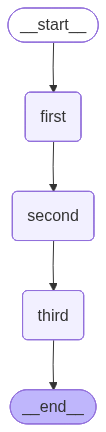

In [18]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
result = app.invoke({
    "name": "Linda",
    "age": 31,
    "skills": ["Python", "Machine Learning", "LangGraph"],
})

print(result['message'])

Linda, welcome to the system! You are 31 years old! Your skills are: Python, Machine Learning, and LangGraph.
